# Data Analysis

Notebook này phân tích dataset object detection theo các tiêu chí chính: tổng số ảnh/object/class, thống kê từng split train/validation/test, class imbalance, kích thước bbox, `relative_area`, và nhóm object `small` / `medium` / `large`.

Các cell visualization bằng slider vẫn được giữ để quan sát ground truth, prediction, oversampling và augmentation.

In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebook_helpers import (
    analyze_box_size_distribution,
    analyze_dataset_splits,
    plot_box_size_distribution,
    plot_dataset_analysis,
    plot_training_input_distribution,
    show_augmentation_comparison_slider,
    show_groundtruth_slider,
    show_predictions_slider,
    show_training_input_slider,
    summarize_training_input,
)

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Phân Tích Dataset

Mặc định nhóm kích thước object theo tỷ lệ diện tích bbox trên diện tích ảnh:
- `small`: `relative_area < 0.01`
- `medium`: `0.01 <= relative_area < 0.10`
- `large`: `relative_area >= 0.10`

Có thể chỉnh `SMALL_RELATIVE_AREA` và `MEDIUM_RELATIVE_AREA` nếu muốn ngưỡng chặt/lỏng hơn.

In [14]:
DATA_ROOT = PROJECT_ROOT / "public"
SPLITS = ("train", "val", "test")
SMALL_RELATIVE_AREA = 0.01
MEDIUM_RELATIVE_AREA = 0.10

dataset_analysis = analyze_dataset_splits(
    data_root=DATA_ROOT,
    splits=SPLITS,
    small_threshold=SMALL_RELATIVE_AREA,
    medium_threshold=MEDIUM_RELATIVE_AREA,
)

print("Dataset root:", dataset_analysis["root"])
print("Size thresholds:", dataset_analysis["size_thresholds"])
print("Class imbalance:", dataset_analysis["imbalance"])

Dataset root: /Users/ngocbao/Documents/Document/Semester6/Image Processing/Final/public
Size thresholds: {'small': 'relative_area < 0.01', 'medium': '0.01 <= relative_area < 0.1', 'large': 'relative_area >= 0.1'}
Class imbalance: {'max_count': 6903, 'min_count': 1009, 'max_min_ratio': 6.841427155599604, 'minority_classes': ['car', 'dog', 'cat']}


In [15]:
print("Tổng quan toàn bộ dataset")
display(dataset_analysis["overall"].round(4))

print("Số ảnh và số object theo từng split")
display(dataset_analysis["splits"].round(4))

print("Số object theo từng class trên toàn dataset")
display(dataset_analysis["class_counts"].round(4))

print("Số object theo class và split")
display(dataset_analysis["class_by_split"])

print("Nhóm kích thước object small / medium / large")
display(dataset_analysis["size_groups"])

print("Thống kê width, height, area, relative_area, aspect_ratio")
display(dataset_analysis["box_summary"].round(6))

Tổng quan toàn bộ dataset


,splits,total_images,total_objects,num_classes,objects_per_image
0,"train, val",9000,12663,5,1.407


Số ảnh và số object theo từng split


,split,annotation_path,image_dir,num_images,num_objects,num_classes,objects_per_image
0,train,/Users/ngocbao/Documents/Document/Semester6/Im...,/Users/ngocbao/Documents/Document/Semester6/Im...,7500,10642,5,1.4189
1,val,/Users/ngocbao/Documents/Document/Semester6/Im...,/Users/ngocbao/Documents/Document/Semester6/Im...,1500,2021,5,1.3473


Số object theo từng class trên toàn dataset


...

split,class,train,val
0,car,1339,283
1,cat,833,176
2,chair,1613,282
3,dog,1028,206
4,person,5829,1074


Nhóm kích thước object small / medium / large


split,size_group,train,val
0,small,1153,249
1,medium,3917,672
2,large,5572,1100


Thống kê width, height, area, relative_area, aspect_ratio


,width,height,area,relative_area,aspect_ratio
count,12663.000000,12663.000000,12663.000000,12663.000000,12663.000000
mean,156.930585,185.484482,38984.065703,0.216798,0.917175
std,122.939433,115.597118,45048.212518,0.246294,0.582754
min,4.000000,5.000000,56.000000,0.000299,0.079602
1%,14.000000,17.000000,322.000000,0.001791,0.230769
5%,23.000000,31.000000,867.100000,0.004883,0.312526
10%,32.000000,45.000000,1577.800000,0.008960,0.366013
25%,60.000000,87.000000,5394.500000,0.030184,0.518694
50%,121.000000,170.000000,20235.000000,0.113159,0.756944
75%,223.000000,269.000000,56914.000000,0.321664,1.148398


array([<Axes: title={'center': 'Images and objects by split'}, xlabel='split', ylabel='Count'>,
       <Axes: title={'center': 'Objects by class'}, xlabel='Class', ylabel='Object count'>,
       <Axes: title={'center': 'Object size groups'}, xlabel='Size group', ylabel='Object count'>],
      dtype=object)

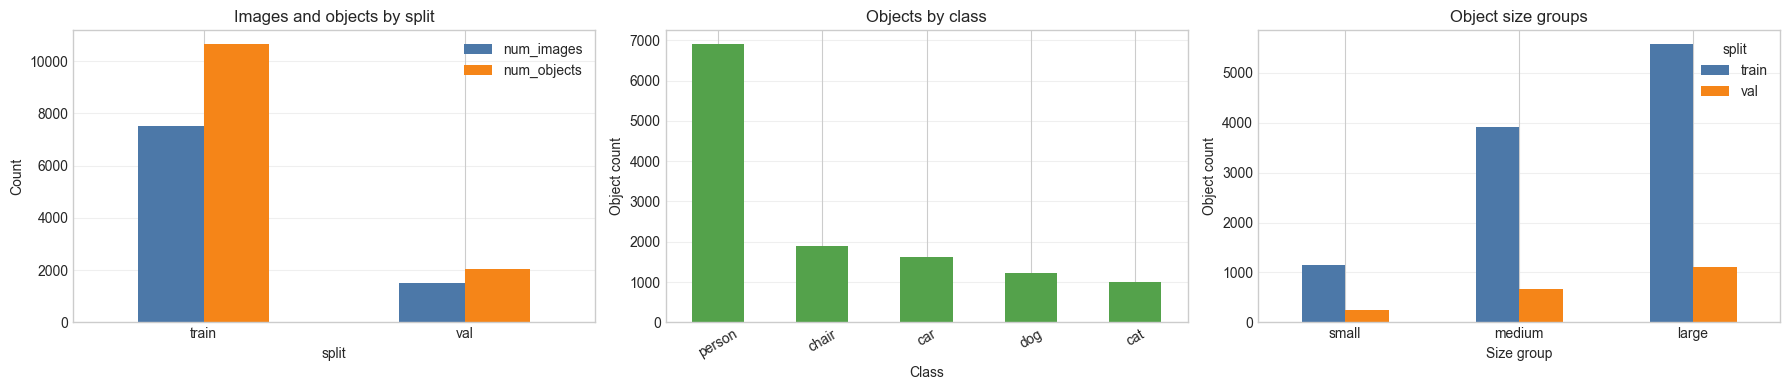

In [16]:
plot_dataset_analysis(dataset_analysis)

In [17]:
box_table = dataset_analysis["box_table"]
print("Một vài box nhỏ nhất theo relative_area")
display(box_table.nsmallest(10, "relative_area")[[
    "split", "image_id", "class", "width", "height", "area", "relative_area", "size_group"
]].round(6))

print("Một vài box lớn nhất theo relative_area")
display(box_table.nlargest(10, "relative_area")[[
    "split", "image_id", "class", "width", "height", "area", "relative_area", "size_group"
]].round(6))

Một vài box nhỏ nhất theo relative_area


,split,image_id,class,width,height,area,relative_area,size_group
2269,train,img_380ef284b2bf.jpg,person,4.0,14.0,56.0,0.000299,small
10356,train,img_f89e4cec493c.jpg,car,8.0,7.0,56.0,0.000299,small
9139,train,img_dde62d4f0815.jpg,person,7.0,11.0,77.0,0.000411,small
10357,train,img_f89e4cec493c.jpg,car,13.0,6.0,78.0,0.000416,small
6107,train,img_97376dee68ee.jpg,car,9.0,10.0,90.0,0.000450,small
6450,train,img_9fb72c392a5b.jpg,person,11.0,9.0,99.0,0.000484,small
4188,train,img_66870b5ba9a4.jpg,person,9.0,9.0,81.0,0.000488,small
9544,train,img_e763b2de0f0d.jpg,car,17.0,5.0,85.0,0.000503,small
2268,train,img_380ef284b2bf.jpg,car,12.0,8.0,96.0,0.000512,small
9021,train,img_daa64064b802.jpg,car,11.0,9.0,99.0,0.000528,small


Một vài box lớn nhất theo relative_area


,split,image_id,class,width,height,area,relative_area,size_group
1129,train,img_1cf5055e55bf.jpg,car,499.0,455.0,227045.0,0.995811,large
1758,train,img_2c8240931f4b.jpg,cat,499.0,449.0,224051.0,0.995782,large
2172,train,img_359e5e349fb3.jpg,person,499.0,436.0,217564.0,0.995716,large
4758,train,img_74fa1912ce54.jpg,cat,499.0,399.0,199101.0,0.995505,large
10388,train,img_f96bff4a8ff2.jpg,dog,499.0,394.0,196606.0,0.995473,large
0,train,img_000c52c6d12f.jpg,dog,499.0,374.0,186626.0,0.995339,large
596,train,img_0fc2d8265bbd.jpg,person,499.0,374.0,186626.0,0.995339,large
1611,train,img_294692cccaf7.jpg,person,499.0,374.0,186626.0,0.995339,large
1899,train,img_2f83e39e0d73.jpg,person,374.0,499.0,186626.0,0.995339,large
2086,train,img_33a0aca152dc.jpg,chair,499.0,374.0,186626.0,0.995339,large


## 2. Visualize Bằng Slider

Duyệt ground truth hoặc prediction bằng slider. Phần này giữ nguyên để quan sát từng ảnh trực tiếp.

In [18]:
# Có thể đổi folder="val" để xem validation.
show_groundtruth_slider(folder="train", data_root=DATA_ROOT)

IntSlider(value=0, continuous_update=False, description='Index', max=7499)

## Training Input Debug

Các cell dưới đây kiểm tra dữ liệu ngay trước khi đưa vào model: phân phối gốc, phân phối sau oversampler, và ảnh tensor sau augmentation.


,stage,images_per_epoch,boxes_per_epoch,mean_boxes_per_image,empty_images
0,raw_dataset,7500,10642,1.4189,2500
1,after_oversampler,7500,11973,1.5964,2306


,class,raw_images,sampled_images,raw_boxes,sampled_boxes,image_ratio_before,image_ratio_after,box_ratio_before,box_ratio_after
0,person,2753,2765,5829,6078,0.3671,0.3687,0.5477,0.5076
4,chair,754,1361,1613,2964,0.1005,0.1815,0.1516,0.2476
2,dog,862,764,1028,927,0.1149,0.1019,0.0966,0.0774
1,car,777,717,1339,1225,0.1036,0.0956,0.1258,0.1023
3,cat,738,693,833,779,0.0984,0.0924,0.0783,0.0651


<Axes: title={'center': 'Training input box ratio before/after oversampling'}, xlabel='Class', ylabel='Ratio'>

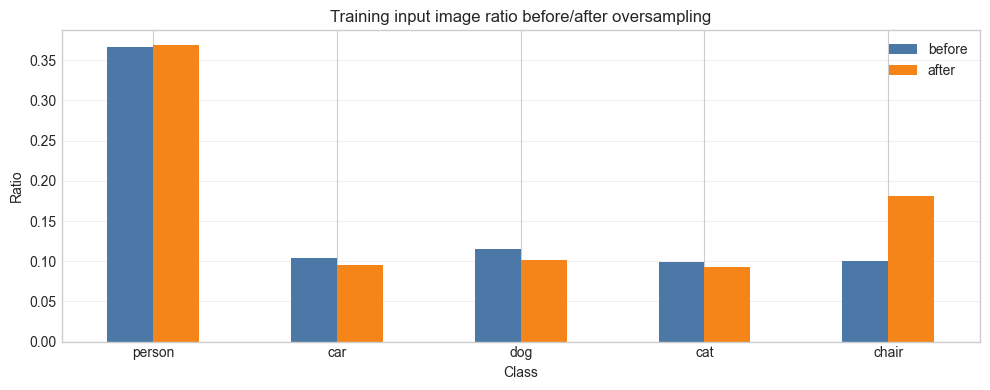

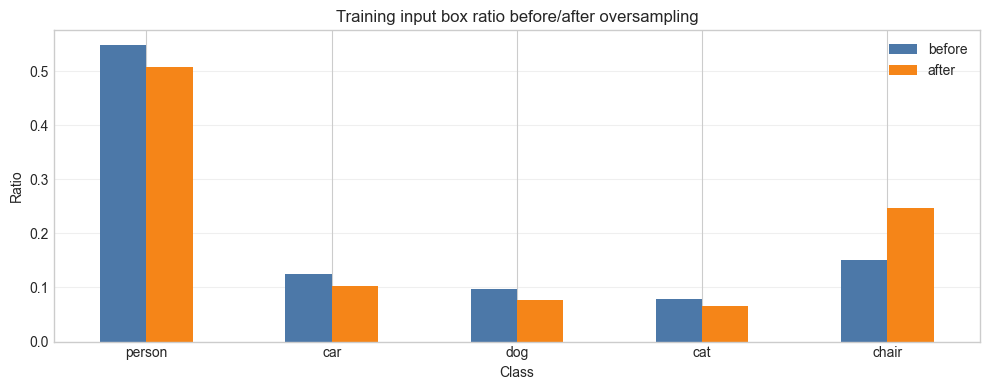

In [19]:
TRAIN_ANNOTATION = PROJECT_ROOT / "public" / "annotations" / "train.json"
TRAIN_IMAGE_DIR = PROJECT_ROOT / "public" / "train" / "images"

OVERSAMPLE_CLASS = "chair"
OVERSAMPLE_FACTOR = 2.0
AUGMENT_PARAMS = {
    "horizontal_flip_probability": 0.5,
    "color_jitter_probability": 0.0,
    "grayscale_probability": 0.0,
}

training_input = summarize_training_input(
    annotation_path=TRAIN_ANNOTATION,
    image_dir=TRAIN_IMAGE_DIR,
    oversample_class=OVERSAMPLE_CLASS,
    oversample_factor=OVERSAMPLE_FACTOR,
    seed=42,
)

display(training_input["summary"].round(4))
display(
    training_input["per_class"]
    .sort_values("image_ratio_after", ascending=False)
    .round(4)
)

plot_training_input_distribution(training_input, ratio_kind="image")
plot_training_input_distribution(training_input, ratio_kind="box")


In [20]:
# Duyệt stream training sau oversampler. Nếu augment=True, ảnh/box là output thật từ OdDataset trước khi vào model.
show_training_input_slider(
    annotation_path=TRAIN_ANNOTATION,
    image_dir=TRAIN_IMAGE_DIR,
    oversample_class=OVERSAMPLE_CLASS,
    oversample_factor=OVERSAMPLE_FACTOR,
    augment=True,
    max_samples=50,
    seed=42,
    **AUGMENT_PARAMS,
)


IntSlider(value=0, continuous_update=False, description='Index', max=49)

In [ ]:
# So sánh cùng một ảnh trước và sau augmentation để kiểm tra bbox có được transform đúng không.
show_augmentation_comparison_slider(
    annotation_path=TRAIN_ANNOTATION,
    image_dir=TRAIN_IMAGE_DIR,
    oversample_class=OVERSAMPLE_CLASS,
    oversample_factor=OVERSAMPLE_FACTOR,
    max_samples=30,
    seed=7,
    **AUGMENT_PARAMS,
)


IntSlider(value=0, continuous_update=False, description='Index', max=29)

## Box Size, Resize, Anchor Analysis

Phần này thống kê bbox nhỏ nhất/lớn nhất theo kích thước gốc và sau resize của Faster R-CNN. Dựa trên `resized_sqrt_area = sqrt(w*h)` ta chọn anchor size hợp lý hơn.


In [22]:
ANCHOR_MIN_SIZE = 512
ANCHOR_MAX_SIZE = 768

box_analysis = analyze_box_size_distribution(
    annotation_path=TRAIN_ANNOTATION,
    image_dir=TRAIN_IMAGE_DIR,
    min_size=ANCHOR_MIN_SIZE,
    max_size=ANCHOR_MAX_SIZE,
    top_k=12,
)

print("Resize đang phân tích:", box_analysis["recommendations"]["current_resize"])
print("Gợi ý anchor sizes:", box_analysis["recommendations"]["recommended_anchor_sizes"])
print("Gợi ý anchor ratios:", box_analysis["recommendations"]["recommended_anchor_ratios"])
print("Default torchvision anchor sizes:", box_analysis["recommendations"]["torchvision_default_anchor_sizes"])
print("Default torchvision anchor ratios:", box_analysis["recommendations"]["torchvision_default_anchor_ratios"])
print(box_analysis["recommendations"]["suggestion"])


Resize đang phân tích: {'min_size': 512, 'max_size': 768}
Gợi ý anchor sizes: [64, 128, 192, 256, 512]
Gợi ý anchor ratios: [0.33, 0.5, 1.0, 2.0]
Default torchvision anchor sizes: [32, 64, 128, 256, 512]
Default torchvision anchor ratios: [0.5, 1.0, 2.0]
Keep min_size/max_size if resized boxes mostly fall between 16 and 512 px. If many resized_sqrt_area values are below 16 px, raise min_size or add a 16 px anchor. If many values exceed 512 px, raise max_size or keep a 512/768 anchor.


,width,height,area,sqrt_area,aspect_ratio,resized_width,resized_height,resized_area,resized_sqrt_area,resize_scale
count,10642.00,10642.00,10642.00,10642.00,10642.00,10642.00,10642.00,10642.00,10642.00,10642.00
mean,156.51,184.82,38756.42,164.38,0.92,220.81,260.34,76610.82,231.68,1.42
std,123.03,115.05,44961.72,108.34,0.58,173.34,160.37,87328.81,151.45,0.13
min,4.00,5.00,56.00,7.48,0.08,5.46,7.57,104.39,10.22,1.02
1%,14.00,17.00,316.64,17.79,0.23,19.11,23.21,627.88,25.06,1.07
5%,23.00,31.05,867.05,29.45,0.31,32.77,44.54,1752.32,41.86,1.29
10%,32.00,45.00,1596.00,39.95,0.37,45.06,64.17,3271.56,57.20,1.37
25%,59.00,87.00,5400.00,73.48,0.52,83.29,122.88,10864.01,104.23,1.37
50%,120.00,169.00,19958.00,141.27,0.76,169.30,240.30,39814.20,199.53,1.37
75%,223.00,268.00,56591.25,237.89,1.15,315.39,380.93,113716.62,337.22,1.53


,class,boxes,min_resized_sqrt_area,p10_resized_sqrt_area,median_resized_sqrt_area,p90_resized_sqrt_area,max_resized_sqrt_area,median_aspect_ratio,p10_aspect_ratio,p90_aspect_ratio
0,car,1339,10.22,35.72,118.09,457.78,617.96,1.59,0.85,2.64
2,chair,1613,15.33,64.84,150.90,340.23,623.93,0.77,0.48,1.45
4,person,5829,10.22,55.33,193.51,419.94,625.19,0.59,0.32,1.09
3,dog,1028,23.96,131.90,328.57,521.09,625.19,1.04,0.61,1.75
1,cat,833,20.89,179.63,401.12,545.08,625.19,1.16,0.64,1.83


array([<Axes: title={'center': 'Resized bbox sqrt(area)'}, xlabel='sqrt(area) after resize', ylabel='Box count'>,
       <Axes: title={'center': 'BBox aspect ratio'}, xlabel='width / height, clipped at 5', ylabel='Box count'>],
      dtype=object)

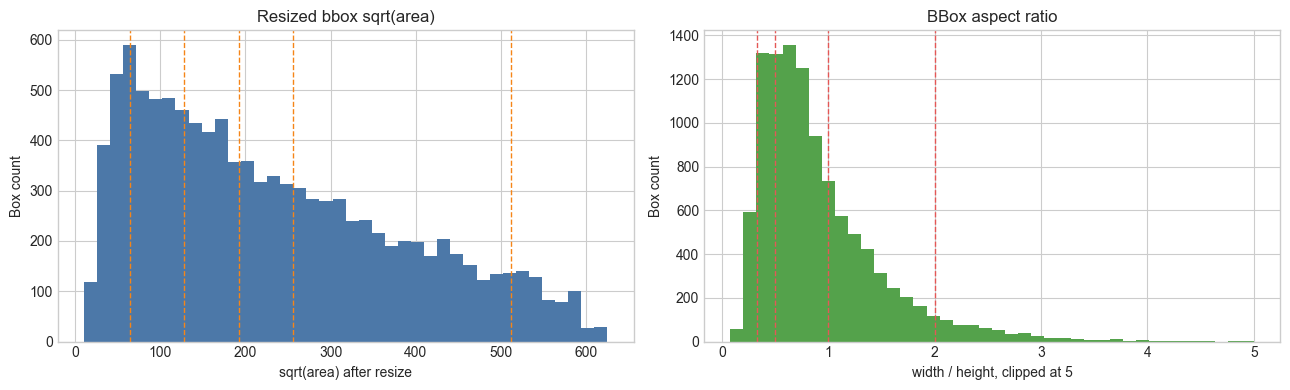

In [23]:
display(box_analysis["summary"].round(2))
display(box_analysis["per_class"].round(2))
plot_box_size_distribution(box_analysis)


In [24]:
print("Smallest boxes after resize")
display(box_analysis["smallest"].round(2))

print("Largest boxes after resize")
display(box_analysis["largest"].round(2))


Smallest boxes after resize


,image_id,class,bbox,width,height,area,aspect_ratio,resized_width,resized_height,resized_area,resized_sqrt_area
2269,img_380ef284b2bf.jpg,person,"[173, 203, 177, 217]",4.0,14.0,56.0,0.29,5.46,19.11,104.39,10.22
10356,img_f89e4cec493c.jpg,car,"[278, 55, 286, 62]",8.0,7.0,56.0,1.14,10.92,9.56,104.39,10.22
9139,img_dde62d4f0815.jpg,person,"[341, 95, 348, 106]",7.0,11.0,77.0,0.64,9.56,15.02,143.54,11.98
10357,img_f89e4cec493c.jpg,car,"[285, 56, 298, 62]",13.0,6.0,78.0,2.17,17.75,8.19,145.40,12.06
6107,img_97376dee68ee.jpg,car,"[345, 196, 354, 206]",9.0,10.0,90.0,0.90,11.52,12.80,147.46,12.14
6450,img_9fb72c392a5b.jpg,person,"[442, 188, 453, 197]",11.0,9.0,99.0,1.22,13.77,11.27,155.14,12.46
2268,img_380ef284b2bf.jpg,car,"[356, 193, 368, 201]",12.0,8.0,96.0,1.50,16.38,10.92,178.96,13.38
9021,img_daa64064b802.jpg,car,"[130, 181, 141, 190]",11.0,9.0,99.0,1.22,15.02,12.29,184.55,13.58
6452,img_9fb72c392a5b.jpg,person,"[393, 192, 403, 204]",10.0,12.0,120.0,0.83,12.52,15.02,188.05,13.71
4188,img_66870b5ba9a4.jpg,person,"[459, 135, 468, 144]",9.0,9.0,81.0,1.00,13.82,13.82,191.10,13.82


Largest boxes after resize


,image_id,class,bbox,width,height,area,aspect_ratio,resized_width,resized_height,resized_area,resized_sqrt_area
340,img_0a169bc6b957.jpg,cat,"[1, 1, 500, 333]",499.0,332.0,165668.0,1.50,766.46,509.95,390859.85,625.19
1116,img_1c8ca9dd496e.jpg,person,"[1, 1, 500, 333]",499.0,332.0,165668.0,1.50,766.46,509.95,390859.85,625.19
3385,img_534f734ed8de.jpg,cat,"[1, 1, 500, 333]",499.0,332.0,165668.0,1.50,766.46,509.95,390859.85,625.19
5829,img_906a7e4865dc.jpg,dog,"[1, 1, 333, 500]",332.0,499.0,165668.0,0.67,509.95,766.46,390859.85,625.19
6509,img_a1449518042d.jpg,cat,"[1, 1, 500, 333]",499.0,332.0,165668.0,1.50,766.46,509.95,390859.85,625.19
6732,img_a5cb61cfc2b6.jpg,cat,"[1, 1, 500, 333]",499.0,332.0,165668.0,1.50,766.46,509.95,390859.85,625.19
7950,img_c0f1836f98f5.jpg,person,"[1, 1, 500, 333]",499.0,332.0,165668.0,1.50,766.46,509.95,390859.85,625.19
347,img_0a81cc5b8b9c.jpg,dog,"[1, 1, 500, 334]",499.0,333.0,166167.0,1.50,764.93,510.47,390473.68,624.88
2942,img_47eb401d90c2.jpg,cat,"[1, 1, 500, 334]",499.0,333.0,166167.0,1.50,764.93,510.47,390473.68,624.88
8866,img_d7809a16561d.jpg,person,"[1, 1, 334, 500]",333.0,499.0,166167.0,0.67,510.47,764.93,390473.68,624.88


In [25]:
# Có thể đổi nhanh resize để xem anchor recommendation thay đổi thế nào.
for min_size, max_size in [(512, 768), (768, 1024), (800, 1333)]:
    analysis = analyze_box_size_distribution(
        annotation_path=TRAIN_ANNOTATION,
        image_dir=TRAIN_IMAGE_DIR,
        min_size=min_size,
        max_size=max_size,
        top_k=5,
    )
    rec = analysis["recommendations"]
    print(
        f"min={min_size}, max={max_size} | "
        f"box sqrt p10/median/p90="
        f"{rec['box_size_after_resize']['p10']:.1f}/"
        f"{rec['box_size_after_resize']['median']:.1f}/"
        f"{rec['box_size_after_resize']['p90']:.1f} | "
        f"anchors={rec['recommended_anchor_sizes']} | "
        f"ratios={rec['recommended_anchor_ratios']}"
    )


min=512, max=768 | box sqrt p10/median/p90=57.2/199.5/462.7 | anchors=[64, 128, 192, 256, 512] | ratios=[0.33, 0.5, 1.0, 2.0]
min=768, max=1024 | box sqrt p10/median/p90=82.2/289.6/671.8 | anchors=[96, 192, 256, 384, 768] | ratios=[0.33, 0.5, 1.0, 2.0]
min=800, max=1333 | box sqrt p10/median/p90=89.6/312.7/724.6 | anchors=[96, 192, 256, 512, 768] | ratios=[0.33, 0.5, 1.0, 2.0]
